In [15]:
#imports
import sys
import os
sys.path.append('../src')

import albumentations as A 
from albumentations.pytorch import ToTensorV2


#Import my custom class
from vision_dataset import CustomAugmentationClass, collate_fn
from torch.utils.data import DataLoader

In [16]:
#Define Transforms
train_transformers = A.Compose([
    A.Resize(640,640),
    A.HorizontalFlip(p=0.3),
    A.GaussianBlur(blur_limit=3, p=1.0),
    A.RandomRotate90(p=0.2),
    A.ColorJitter(p=0.2),
    A.SaltAndPepper(amount=(0.1, 0.2), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.1),
    ToTensorV2()
], 
bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids'])
)

val_test_transformers = A.Compose([
    A.Resize(640, 640),
    ToTensorV2()
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids'])
)

C:\Users\taher\AppData\Local\Temp\ipykernel_20776\239839552.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=64, max_width=64, p=0.1),


In [17]:
# Create Datasets

DATA_ROOT = "../data/"

train_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "train2019"),
    json_path=os.path.join(DATA_ROOT, "instances_train2019.json"),
    transforms=train_transformers
)

val_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "val2019"),
    json_path=os.path.join(DATA_ROOT, "instances_val2019.json"),
    transforms=val_test_transformers
)

test_dataset = CustomAugmentationClass(
    images_dir=os.path.join(DATA_ROOT, "test2019"),
    json_path=os.path.join(DATA_ROOT, "instances_test2019.json"),
    transforms=val_test_transformers
)

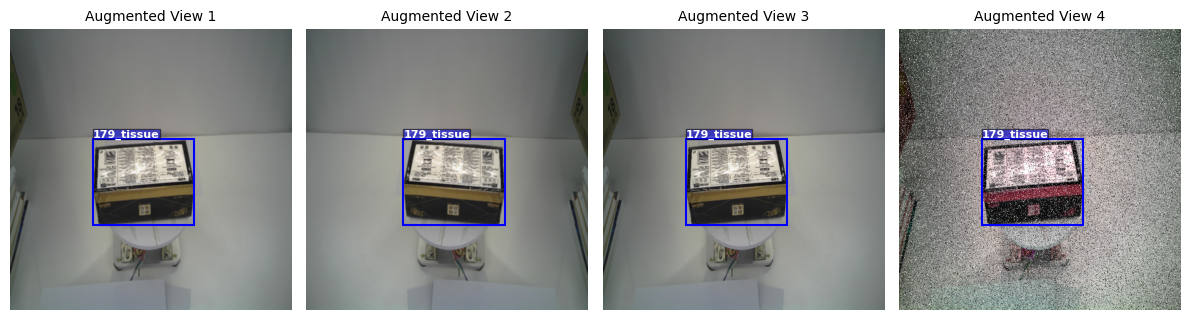

In [18]:
#Draw 4 random samples from the dataset with their boxes:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random 

#mapping dictionary (ID to Name):
id_to_name = {cat['id']: cat['name'] for cat in train_dataset.categories}


#create the plot: 
fig, axes = plt.subplots(1,4,figsize=(12,10))
axes = axes.flatten() #to loop easily in 1D

random_index = random.randint(0,len(train_dataset)-1)
for i in range(4):
    #pick a random sample:
    img,target = train_dataset[random_index]

    #convert from tensor to numpy for plotting:
    plot_img = img.permute(1,2,0).numpy()

    axes[i].imshow(plot_img)

    #draw the boxes/labels for the specific sample:
    boxes = target['boxes']
    labels = target['labels']

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1

        # 1. Draw the Rectangle
        rect = patches.Rectangle(xy=(x1, y1), width=width, height=height, 
                                 linewidth=1.5, edgecolor='blue', facecolor='none')
        axes[i].add_patch(rect)

        # 2. Get the actual name using the ID (using id_to_name dictionary)
        class_id = label.item() # Convert tensor to int
        class_name = id_to_name.get(class_id, f"ID: {class_id}")

        # 3. Add the text label
        # We put it at (x1, y1) which is the top-left corner
        axes[i].text(x=x1, y=y1, s=class_name, 
                     color='white', fontsize=8, fontweight='bold',
                     va='bottom', ha='left', # 'bottom' makes it sit ON the line
                     bbox=dict(facecolor='blue', alpha=0.5, pad=0)) # Added a small background for readability

    axes[i].set_title(f"Augmented View {i+1}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

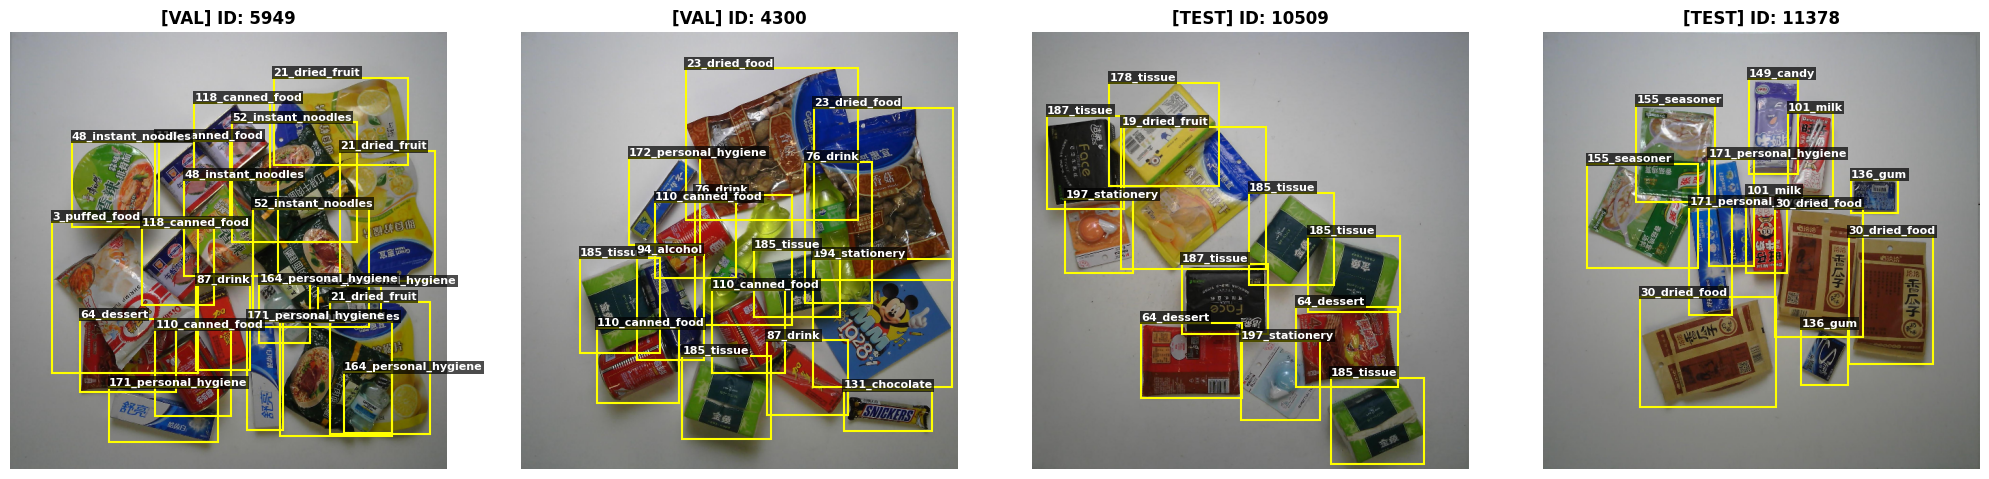

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random 

# 1.get 2 random samples from each of the val and test datasets
val_indices = random.sample(range(len(val_dataset)), 2)
test_indices = random.sample(range(len(test_dataset)), 2)

# put them in one list to loop over them in one loop
# each element is (dataset, index, type_name) e.g.: (val_dataset, 5, "VAL")
samples = [
    (val_dataset, val_indices[0], "VAL"),
    (val_dataset, val_indices[1], "VAL"),
    (test_dataset, test_indices[0], "TEST"),
    (test_dataset, test_indices[1], "TEST")
]

# 2.create a plot with 4 subplots (2 for val and 2 for test)
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, (ds, idx, name) in enumerate(samples):
    img, target = ds[idx]
    plot_img = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(plot_img)
    
    # draw the boxes/labels for the specific sample:
    boxes = target['boxes']
    labels = target['labels']
    
    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = box.tolist()
        width, height = x2 - x1, y2 - y1
        
        rect = patches.Rectangle((x1, y1), width, height, 
                                 linewidth=1.5, edgecolor='yellow', facecolor='none')
        axes[i].add_patch(rect)
        
        # add the class name using the id_to_name mapping Dictionary:
        class_id = label.item()
        class_name = id_to_name.get(class_id, f"ID: {class_id}")
        axes[i].text(x1, y1, class_name, color='white', fontsize=8, 
                     fontweight='bold', va='bottom', 
                     bbox=dict(facecolor='black', alpha=0.7, pad=1, edgecolor='none'))

    # Title each subplot with the dataset type and the sample ID
    axes[i].set_title(f"[{name}] ID: {idx}", fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# --- Hyperparameters ---
# Adjust BATCH_SIZE based on GPU VRAM (32 is great for your RX 9070 XT)
BATCH_SIZE = 32 
# NUM_WORKERS speeds up data loading by using multiple CPU cores
NUM_WORKERS = 6 

# --- Initialize DataLoaders ---

# 1. Train Loader: Includes Augmentations and Shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# 2. Validation Loader: For monitoring performance during training
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# 3. Test Loader: For final evaluation after training is complete
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

# --- Sanity Check ---
# Fetch one batch to ensure everything is wired correctly
images, targets = next(iter(train_loader))
print(f"Successfully loaded a batch of {len(images)} images.")
print(f"Batch Image Tensor Shape: {images[0].shape}") # Should be [3, 640, 640]

Successfully loaded a batch of 32 images.
Batch Image Tensor Shape: torch.Size([3, 640, 640])
